# 01 — Harpd AI Market Overview

## Question

How is the Harpd product catalog composed across categories, and how much paid
placement does it actually carry?

The goal is a factual description of the catalog as published. This notebook does
not rank products by quality, because the dataset contains no quality measurement.


## Dataset

| Item | Value |
|---|---|
| Catalog | `data/products/products.json` — 1,122 records |
| Category boards | `data/rankings/categories.json` — 28 boards |
| Market index | `data/research/ai-market-index.json` — 27 categories |
| Registry | `data/manifest.json` |
| Raw base | `https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/` |
| Licence | CC BY 4.0 |

The notebooks fetch from the public raw URL by default so a third party can
reproduce every number. Set `HARPD_DATA_BASE` to a local clone to run offline:

```bash
HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert --execute --inplace notebooks/01-ai-market-overview.ipynb
```

**Domain caveat.** `rankPoints` measures promotional placement bought with
Credits. It is not an editorial quality score, and nothing below treats it as one.


## Method

1. Load the catalog, the category boards and the market index from the dataset base.
2. `analysis.market_composition` groups products by category and computes each
   category's share of total listings. This is a **count ordering**.
3. `analysis.placement_concentration` counts how many products carry
   `rankPoints > 0` and sums the total points across the catalog.
4. `analysis.category_boards` reports each board's listing count, ranked-product
   count and the publisher-declared board state.
5. Cross-check the parsed row count against the `recordCount` published in
   `manifest.json`.

Every figure is produced by integer counting or share division over the loaded
records. No value is imputed, smoothed or modelled.


## Analysis

In [1]:
import os
import sys
from pathlib import Path

# Make the repository root importable no matter where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "harpd_research").is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from harpd_research import analysis, loader

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print("repo root :", ROOT)
print("data base :", loader.resolved_data_base())
print("pandas    :", pd.__version__)
print()
print("DOMAIN CAVEAT")
print(analysis.PLACEMENT_CAVEAT)


repo root : /Users/shankou/harpd/harpd-ai-research-notebooks
data base : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/
pandas    : 3.0.5

DOMAIN CAVEAT
Rank Points are promotional placement bought with Credits — NOT an editorial quality score. Any ordering below is a promotional placement ordering, not a ranking of product quality.


In [2]:
products = loader.load_products()
categories = loader.load_categories()
market_index = loader.load_ai_market_index()
manifest = loader.load_manifest()

print("products          :", products.shape)
print("generatedAt       :", products.attrs.get("generatedAt"))
print("lastUpdated       :", products.attrs.get("lastUpdated"))
print("categories        :", categories.shape)
print("market index rows :", market_index.shape)
print("manifest version  :", manifest.get("version"), "| updatedAt", manifest.get("updatedAt"))
print()
print("catalog columns:")
print(list(products.columns))

products          : (1122, 13)
generatedAt       : 2026-09-16T10:37:21.210Z
lastUpdated       : 2026-09-15T03:58:43.395Z
categories        : (28, 11)
market index rows : (27, 10)
manifest version  : 2026.9 | updatedAt 2026-09-16T10:37:21.880Z

catalog columns:
['id', 'name', 'slug', 'url', 'category', 'categoryName', 'rank', 'rankPoints', 'verified', 'updatedAt', 'website', 'description', 'productType']


In [3]:
# Cross-check the parsed row count against the published recordCount.
published = {d["id"]: d["recordCount"] for d in manifest["datasets"]}
parsed = len(products)
declared = published.get("products")
print(f"parsed rows           : {parsed:,}")
print(f"manifest recordCount  : {declared:,}")
print("match                 :", parsed == declared)

# Sanity: is `rank` a contiguous 1..N sequence with no duplicates?
ranks = products["rank"].dropna().astype(int)
print()
print("rank min/max          :", int(ranks.min()), "/", int(ranks.max()))
print("distinct ranks        :", ranks.nunique(), "(== row count means no duplicates)")

parsed rows           : 1,122
manifest recordCount  : 1,122
match                 : True

rank min/max          : 1 / 1122
distinct ranks        : 1122 (== row count means no duplicates)


In [4]:
composition = analysis.market_composition(products)
print(f"{len(composition)} categories, {int(composition['productCount'].sum()):,} listings total")
print()
display(composition.head(15))

27 categories, 1,122 listings total



,category,categoryName,productCount,sharePct
0,other,Other,335,29.86
1,developer,Developer,141,12.57
2,agents,Agents,84,7.49
3,ai-media,AI Media,64,5.70
4,marketing,Marketing,64,5.70
5,seo,SEO,60,5.35
6,productivity,Productivity,47,4.19
7,audio,Audio,40,3.57
8,business,Business,34,3.03
9,education,Education,30,2.67


In [5]:
placement = analysis.placement_concentration(products)
placement_frame = pd.DataFrame([placement]).drop(columns=["caveat"])
display(placement_frame.T.rename(columns={0: "value"}))

,value
totalProducts,1122
productsWithPlacement,1
productsWithoutPlacement,1121
placementCoveragePct,0.0891
totalRankPoints,233.0
maxRankPoints,233.0
largestPlacementSharePct,100.0
distinctPlacementValues,2
has_meaningful_placement,False


In [6]:
board_state = (
    categories.groupby("state")
    .agg(categories=("slug", "nunique"), products=("productCount", "sum"))
    .reset_index()
    .sort_values("products", ascending=False)
    .reset_index(drop=True)
)
display(board_state)

,state,categories,products
0,LISTED_NO_RP,26,1058
1,ACTIVE,1,64
2,EMPTY,1,0


In [7]:
boards = analysis.category_boards(categories)
display(boards.head(12))

,slug,name,productCount,rankedProductCount,totalRankPoints,state,topRankOpen
0,other,Other,335,0,0,LISTED_NO_RP,True
1,developer,Developer,141,0,0,LISTED_NO_RP,True
2,agents,Agents,84,0,0,LISTED_NO_RP,True
3,ai-media,AI Media,64,1,233,ACTIVE,False
4,marketing,Marketing,64,0,0,LISTED_NO_RP,True
5,seo,SEO,60,0,0,LISTED_NO_RP,True
6,productivity,Productivity,47,0,0,LISTED_NO_RP,True
7,audio,Audio,40,0,0,LISTED_NO_RP,True
8,business,Business,34,0,0,LISTED_NO_RP,True
9,education,Education,30,0,0,LISTED_NO_RP,True


## Visualization

Two charts, both descriptive:

1. The 12 largest categories by listing count — a count ordering, explicitly not a
   quality ordering.
2. Placement coverage: how many products carry any Rank Points at all.


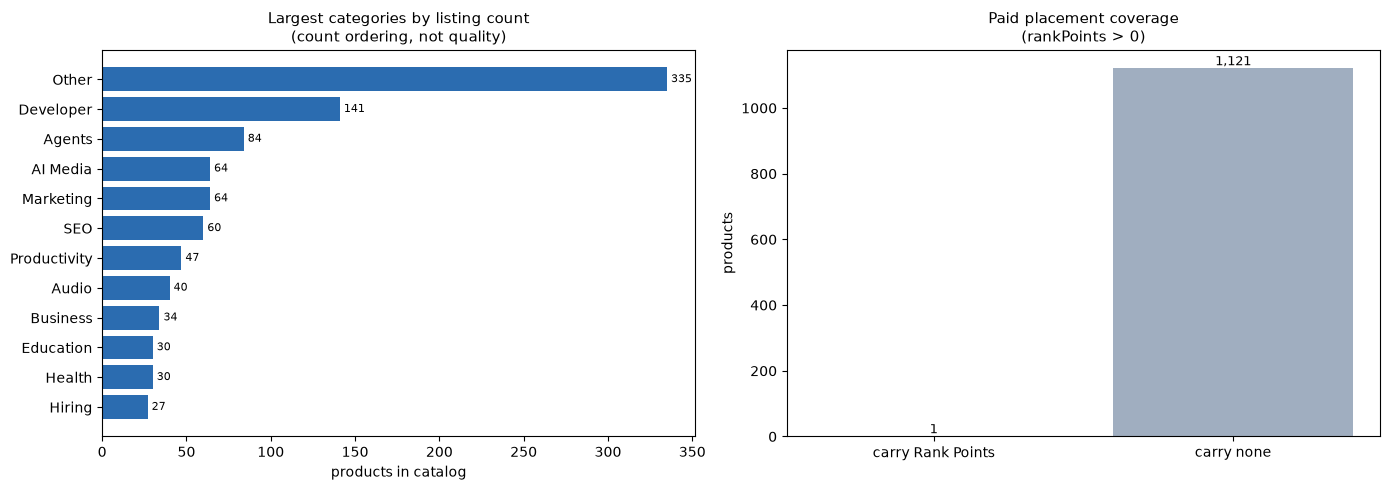

Placement coverage: 0.0891% (1 of 1,122)


In [8]:
top = composition.head(12).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top["categoryName"], top["productCount"], color="#2b6cb0")
axes[0].set_title("Largest categories by listing count\n(count ordering, not quality)", fontsize=11)
axes[0].set_xlabel("products in catalog")
for y, v in enumerate(top["productCount"]):
    axes[0].text(v, y, f" {int(v)}", va="center", fontsize=8)

labels = ["carry Rank Points", "carry none"]
values = [placement["productsWithPlacement"], placement["productsWithoutPlacement"]]
bars = axes[1].bar(labels, values, color=["#c05621", "#a0aec0"])
axes[1].set_title("Paid placement coverage\n(rankPoints > 0)", fontsize=11)
axes[1].set_ylabel("products")
for bar, v in zip(bars, values, strict=False):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("Placement coverage:", f"{placement['placementCoveragePct']}%",
      f"({placement['productsWithPlacement']:,} of {placement['totalProducts']:,})")

## Findings

Computed below from the loaded data. If a line reports a zero or a near-zero, that
is the finding — it is not filled in with an estimate.


In [9]:
findings = [
    f"The catalog contains {placement['totalProducts']:,} products across "
    f"{products['category'].nunique()} categories.",

    f"The largest category by listing count is '{composition.iloc[0]['categoryName']}' "
    f"with {int(composition.iloc[0]['productCount']):,} products "
    f"({composition.iloc[0]['sharePct']}% of the catalog).",

    f"Only {placement['productsWithPlacement']:,} of {placement['totalProducts']:,} "
    f"products ({placement['placementCoveragePct']}%) carry any Rank Points; "
    f"{placement['productsWithoutPlacement']:,} carry zero.",

    f"Total Rank Points across the entire catalog: {placement['totalRankPoints']:,.0f}, "
    f"across {placement['distinctPlacementValues']} distinct point values.",

    "Board states: " + "; ".join(
        f"{r.state} = {int(r.categories)} categories / {int(r.products):,} products"
        for r in board_state.itertuples()
    ) + ".",

    f"{int(products['verified'].sum())} of {len(products):,} products are marked verified.",

    f"{int(products['description'].isna().sum())} products have no description; "
    f"{int(products['productType'].isna().sum())} have no productType.",

    "Placement coverage is near zero, so this notebook deliberately does not compute "
    "a placement distribution, a placement leaderboard, or any concentration "
    "statistic beyond raw counts. The data cannot support them.",
]

for i, line in enumerate(findings, 1):
    print(f"{i}. {line}")

1. The catalog contains 1,122 products across 27 categories.
2. The largest category by listing count is 'Other' with 335 products (29.86% of the catalog).
3. Only 1 of 1,122 products (0.0891%) carry any Rank Points; 1,121 carry zero.
4. Total Rank Points across the entire catalog: 233, across 2 distinct point values.
5. Board states: LISTED_NO_RP = 26 categories / 1,058 products; ACTIVE = 1 categories / 64 products; EMPTY = 1 categories / 0 products.
6. 1 of 1,122 products are marked verified.
7. 31 products have no description; 1033 have no productType.
8. Placement coverage is near zero, so this notebook deliberately does not compute a placement distribution, a placement leaderboard, or any concentration statistic beyond raw counts. The data cannot support them.


## Limitations

- **Rank Points are promotional placement bought with Credits — NOT a quality
  score.** No ordering in this notebook is a ranking of product quality.
- Harpd holds no first-party measurement of third-party traffic, revenue or user
  reviews. Those figures are absent from the dataset and are not estimated here.
- A large listing count is not a large market. It is a large number of *discovered
  listings*, which reflects discovery effort as much as market activity.
- 31 records have no description and 1,033 have no `productType`, so
  description-derived or type-derived analysis would silently drop most of the
  catalog.
- This is a single snapshot. No growth rate, trend or period-over-period change is
  computed, because one snapshot cannot support one.
- Category assignment is publisher-assigned and not independently audited.
- `rankPoints` is concentrated in a single product, so any "average placement"
  figure would be dominated by one record and would be misleading. None is reported.


## Reproducibility

In [10]:
import platform
import sys

print("Reproduce this notebook")
print("=" * 60)
print("python :", sys.version.split()[0], "on", platform.platform())
print("pandas :", pd.__version__)
print("data   :", loader.resolved_data_base())
print()
print("From a clean machine:")
print("  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks")
print("  cd harpd-ai-research-notebooks")
print("  python -m venv .venv && . .venv/bin/activate")
print("  pip install -r requirements.txt")
print("  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>")
print()
print("Offline / pinned snapshot:")
print("  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...")


Reproduce this notebook
python : 3.13.12 on macOS-26.6.2-arm64-arm-64bit-Mach-O
pandas : 3.0.5
data   : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/

From a clean machine:
  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks
  cd harpd-ai-research-notebooks
  python -m venv .venv && . .venv/bin/activate
  pip install -r requirements.txt
  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>

Offline / pinned snapshot:
  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...


## Sources

- Dataset registry: <https://github.com/harpd-dev/harpd-ai-datasets>
- Canonical data home: <https://harpd.com/data/>
- Catalog file: `data/products/products.json`
- Category boards: `data/rankings/categories.json`
- Market index: `data/research/ai-market-index.json`
- Rank methodology (publisher): <https://harpd.com/rank/methodology/>

**Licence.** All Harpd dataset content is published under CC BY 4.0.

**Attribution.** Harpd (<https://harpd.com>).

**Not a source for.** Product quality, traffic, revenue, review scores or
market size. None of those are measured by these datasets, and none are
estimated in this notebook.
